# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR

In [3]:
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [4]:
import shap

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [6]:
from platform import python_version

print(python_version())



3.10.12


In [7]:
!which python3

/usr/bin/python3


In [8]:
print(np.__version__)

1.26.3


# Load dataset

In [6]:
tt_set = pd.read_pickle("pickle_files/training_data_bbd.pkl")

In [7]:
tt_set.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,s100,0,0,0,0,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [8]:
tt_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 251242 entries, Line to BBD
dtypes: float64(4), int64(251237), object(1)
memory usage: 4.7+ GB


In [9]:
#Final_data= Final_data.drop(['new_line'], axis=1)
tt_set.set_index('Line', inplace=True)
tt_set.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,0,0,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,0,0,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014,0,0,0,0,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014,0,0,0,0,0,0,0,0,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [9]:
snps = Final_data.iloc[:, 0:251229]
snps.head()

NameError: name 'Final_data' is not defined

In [18]:
prt = Final_data.iloc[:, 251237:]
prt.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


In [10]:
full_pheno = tt_set.iloc[:, 251229:]
full_pheno.head()

,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,
s100,9.5000,6.26667,154.700,5.66667,1,0,0,0,0,0,1,61
s100,10.2200,7.19333,130.000,1.80000,0,1,0,0,0,0,1,37
s100,10.2133,4.00000,116.000,3.40000,0,0,1,0,0,0,1,43
s1014,10.3667,7.76667,111.733,8.66667,1,0,0,0,0,0,1,77
s1014,11.8200,7.78667,73.000,2.60000,0,1,0,0,0,0,1,42


In [32]:
snps_loc= Final_data.drop(['BBD', 'LL',	'LW', 'MD',	'PLH', 'PRT'], axis=1)
snps_loc.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,0,2,2,0,2,0,0,0,0,1


In [33]:
snps_all= Final_data.drop(['MD', 'PRT'], axis=1)
snps_all.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52267177,Chr20_52267897,Chr20_52270629,BBD,LL,LW,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,61.0,9.5000,6.26667,154.700,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,37.0,10.2200,7.19333,130.000,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,77.0,10.3667,7.76667,111.733,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,42.0,11.8200,7.78667,73.000,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,2,0,0,62.0,14.2800,10.22000,95.700,0,0,1


In [ ]:
# Split training set into training and validation

In [52]:
X_train, X_test, y_train, y_test = train_test_split(snps, prt, test_size=0.2, random_state=42)

In [142]:
xgbreg = xgb.XGBRegressor(n_jobs =-1 , gamma= 1.0, learning_rate = 0.1, max_depth=7, n_estimators= 200)

In [143]:
xgbreg.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=1.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=None, ...)

In [144]:
y_pred_xgboost = xgbreg.predict(X_test)

In [145]:
r2_score(y_test, y_pred_xgboost)

-0.15247130393981934

In [146]:
mse = mean_squared_error(y_test, y_pred_xgboost)

In [147]:
rmse = np.sqrt(mse)
print(rmse)

26.116685046019313


# Define all functions

In [6]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}


In [8]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [9]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr




#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [10]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [11]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [9]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [13]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# GWAS dataset

In [18]:
#Load file
genotype = pd.read_csv('../gwas_bbd/top_5percent_snps.012', sep='\t', header=None)
genotype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Columns: 12562 entries, 0 to 12561
dtypes: int64(12562)
memory usage: 125.6 MB


In [19]:
genotype.head()

,0,1,2,3,4,5,6,7,8,9,...,12552,12553,12554,12555,12556,12557,12558,12559,12560,12561
0,0,0,0,0,2,1,0,0,1,0,...,0,0,0,0,0,0,0,2,0,0
1,1,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,2,0,0,0,2,1,0,0,1,0,...,0,0,0,0,0,0,0,2,0,0
3,3,0,0,0,2,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4,4,0,1,0,0,0,0,2,0,0,...,2,2,0,2,0,0,0,0,2,0


In [20]:
genotype.set_index(genotype.columns[0], inplace =True)
genotype.head()

,1,2,3,4,5,6,7,8,9,10,...,12552,12553,12554,12555,12556,12557,12558,12559,12560,12561
0,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,2,1,0,0,1,0,1,...,0,0,0,0,0,0,0,2,0,0
1,0,1,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,2,1,0,0,1,0,1,...,0,0,0,0,0,0,0,2,0,0
3,0,0,0,2,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,1,0,0,0,0,2,0,0,2,...,2,2,0,2,0,0,0,0,2,0


In [21]:
column_names = pd.read_csv('../gwas_bbd/id_names_top5.txt', sep=' ', header=None)

In [22]:
column_names.head

<bound method NDFrame.head of                     0
0         Chr1_124994
1         Chr1_131286
2         Chr1_131374
3         Chr1_132094
4         Chr1_132416
...               ...
12556  Chr20_51859725
12557  Chr20_51891017
12558  Chr20_51977670
12559  Chr20_52108115
12560  Chr20_52247340

[12561 rows x 1 columns]>

In [23]:
genotype.columns = column_names
genotype.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1311 entries, 0 to 1310
Columns: 12561 entries, ('Chr1_124994',) to ('Chr20_52247340',)
dtypes: int64(12561)
memory usage: 125.6 MB


In [24]:
genotype.head()

,"(Chr1_124994,)","(Chr1_131286,)","(Chr1_131374,)","(Chr1_132094,)","(Chr1_132416,)","(Chr1_171769,)","(Chr1_212835,)","(Chr1_237460,)","(Chr1_249303,)","(Chr1_345210,)",...,"(Chr20_51494122,)","(Chr20_51594636,)","(Chr20_51666785,)","(Chr20_51684283,)","(Chr20_51840551,)","(Chr20_51859725,)","(Chr20_51891017,)","(Chr20_51977670,)","(Chr20_52108115,)","(Chr20_52247340,)"
0,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,2,1,0,0,1,0,1,...,0,0,0,0,0,0,0,2,0,0
1,0,1,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,2,1,0,0,1,0,1,...,0,0,0,0,0,0,0,2,0,0
3,0,0,0,2,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,1,0,0,0,0,2,0,0,2,...,2,2,0,2,0,0,0,0,2,0


In [25]:
#Adding row names
rows= pd.read_csv('../gwas_bbd/top_5percent_indv.txt', header=None)
rows.head()

,0
0,s63
1,s64
2,s66
3,s70
4,s71


In [26]:
genotype.index = rows
genotype.head()

,"(Chr1_124994,)","(Chr1_131286,)","(Chr1_131374,)","(Chr1_132094,)","(Chr1_132416,)","(Chr1_171769,)","(Chr1_212835,)","(Chr1_237460,)","(Chr1_249303,)","(Chr1_345210,)",...,"(Chr20_51494122,)","(Chr20_51594636,)","(Chr20_51666785,)","(Chr20_51684283,)","(Chr20_51840551,)","(Chr20_51859725,)","(Chr20_51891017,)","(Chr20_51977670,)","(Chr20_52108115,)","(Chr20_52247340,)"
"(s63,)",0,0,0,2,1,0,0,1,0,1,...,0,0,0,0,0,0,0,2,0,0
"(s64,)",0,1,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
"(s66,)",0,0,0,2,1,0,0,1,0,1,...,0,0,0,0,0,0,0,2,0,0
"(s70,)",0,0,0,2,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
"(s71,)",0,1,0,0,0,0,2,0,0,2,...,2,2,0,2,0,0,0,0,2,0


In [28]:
genotype.to_csv('genotype_top5_percent_bbd.txt', sep ='\t', index = True)

In [29]:
!sed 's/[,()\x27]//g'  genotype_top5_percent_bbd.txt > genotype_top5_percent_bbd_new.txt

In [30]:
#Load the genotype data
genotype_new = pd.read_csv('genotype_top5_percent_bbd_new.txt', sep = '\t')
genotype_new.head()

,Unnamed: 0,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,...,Chr20_51494122,Chr20_51594636,Chr20_51666785,Chr20_51684283,Chr20_51840551,Chr20_51859725,Chr20_51891017,Chr20_51977670,Chr20_52108115,Chr20_52247340
0,s63,0,0,0,2,1,0,0,1,0,...,0,0,0,0,0,0,0,2,0,0
1,s64,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,s66,0,0,0,2,1,0,0,1,0,...,0,0,0,0,0,0,0,2,0,0
3,s70,0,0,0,2,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4,s71,0,1,0,0,0,0,2,0,0,...,2,2,0,2,0,0,0,0,2,0


In [31]:
genotype_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Columns: 12562 entries, Unnamed: 0 to Chr20_52247340
dtypes: int64(12561), object(1)
memory usage: 125.6+ MB


In [32]:
#Setting the index and naming the index column 
genotype_new = genotype_new.rename(columns={genotype_new.columns[0]: 'Line'})
genotype_new.set_index(genotype_new.columns[0])

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51494122,Chr20_51594636,Chr20_51666785,Chr20_51684283,Chr20_51840551,Chr20_51859725,Chr20_51891017,Chr20_51977670,Chr20_52108115,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s63,0,0,0,2,1,0,0,1,0,1,...,0,0,0,0,0,0,0,2,0,0
s64,0,1,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
s66,0,0,0,2,1,0,0,1,0,1,...,0,0,0,0,0,0,0,2,0,0
s70,0,0,0,2,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
s71,0,1,0,0,0,0,2,0,0,2,...,2,2,0,2,0,0,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s2894,1,1,1,0,0,0,1,0,0,0,...,2,0,0,2,0,0,0,0,0,0
s2895,1,1,1,0,0,0,2,0,0,2,...,2,2,1,0,0,0,0,0,0,0
s2896,0,0,0,2,0,1,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0


In [33]:
full_pheno.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LL                 2536 non-null   float64
 1   LW                 2536 non-null   float64
 2   PLH                2536 non-null   float64
 3   VBN                2536 non-null   float64
 4   BeiJing_2013       2536 non-null   int64  
 5   HeNan_2014         2536 non-null   int64  
 6   HeNan_2015         2536 non-null   int64  
 7   HeiLongJiang_2014  2536 non-null   int64  
 8   HeiLongJiang_2015  2536 non-null   int64  
 9   improved_cultivar  2536 non-null   int64  
 10  landrace           2536 non-null   int64  
 11  BBD                2536 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 257.6+ KB


In [34]:
gwas_data = pd.merge(genotype_new, full_pheno, on='Line', how='outer', indicator=False)
gwas_data.head()

,Line,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s100,0,0,0,0,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
1,s100,0,0,0,0,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
2,s100,0,0,0,0,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
3,s101,1,0,0,0,0,0,1,0,0,...,58.000,2.60000,0,0,0,0,1,0,1,53
4,s1014,0,0,0,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77


In [36]:
gwas_data = gwas_data.set_index('Line')
gwas_data.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,0,0,0,0,0,0,2,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,0,0,0,0,0,0,2,...,116.000,3.40000,0,0,1,0,0,0,1,43
s101,1,0,0,0,0,0,1,0,0,0,...,58.000,2.60000,0,0,0,0,1,0,1,53
s1014,0,0,0,0,0,0,0,0,0,1,...,111.733,8.66667,1,0,0,0,0,0,1,77


In [34]:
gwas_data= gwas_data.drop(['index'], axis=1)

In [37]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 12573 entries, Chr1_124994 to BBD
dtypes: float64(4), int64(12569)
memory usage: 243.3+ MB


In [38]:
gwas_data.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,0,0,0,0,0,0,2,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,0,0,0,0,0,0,2,...,116.000,3.40000,0,0,1,0,0,0,1,43
s101,1,0,0,0,0,0,1,0,0,0,...,58.000,2.60000,0,0,0,0,1,0,1,53
s1014,0,0,0,0,0,0,0,0,0,1,...,111.733,8.66667,1,0,0,0,0,0,1,77


# GWAS all traits

In [10]:
#gwas_data.to_pickle("GWAS_top5percent_bbd_data.pkl")
gwas_data = pd.read_pickle("../pickle_files/GWAS_top5percent_bbd_data.pkl")
gwas_data.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,0,0,0,0,0,0,2,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,0,0,0,0,0,0,2,...,116.000,3.40000,0,0,1,0,0,0,1,43
s101,1,0,0,0,0,0,1,0,0,0,...,58.000,2.60000,0,0,0,0,1,0,1,53
s1014,0,0,0,0,0,0,0,0,0,1,...,111.733,8.66667,1,0,0,0,0,0,1,77


In [11]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 12573 entries, Chr1_124994 to BBD
dtypes: float64(4), int64(12569)
memory usage: 243.3+ MB


In [12]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [13]:
gwas_all= gwas_data.drop(['BBD'], axis=1)
gwas_all.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s101,1,0,0,0,0,0,1,0,0,0,...,9.97400,58.000,2.60000,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1


In [14]:
gwas_all_dupe= gwas_data.drop(['BBD'], axis=1)
gwas_all_dupe.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s101,1,0,0,0,0,0,1,0,0,0,...,9.97400,58.000,2.60000,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1


# Run models

In [20]:
X_train, X_test, y_train, y_test = train_test_split(gwas_all, gwas_y, test_size=0.1, random_state=42)

In [21]:
X_train.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2502,0,2,0,0,0,0,2,0,0,2,...,3.82667,89.0,1.2,0,0,1,0,0,1,0
s286,0,0,0,0,0,0,1,0,0,0,...,3.18667,86.6,3.4,0,0,1,0,0,1,0
s382,0,0,0,2,2,0,0,2,0,0,...,7.96000,95.0,4.0,0,1,0,0,0,0,1
s789,1,1,1,0,0,0,2,0,0,2,...,6.97333,35.0,1.6,0,0,1,0,0,1,0
s691,0,0,0,2,0,0,1,0,0,0,...,6.00667,61.0,3.4,0,0,1,0,0,1,0


In [22]:
X_train = X_train.to_numpy()

In [23]:
y_train = y_train.to_numpy()

In [22]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.40968133192055445), ('colsample_bytree', 1.0), ('gamma', 0.49999999999999994), ('learning_rate', 0.02295093530384226), ('max_delta_step', 13), ('max_depth', 23), ('min_child_weight', 9), ('n_estimators', 200), ('reg_alpha', 0.014047443714408019), ('reg_lambda', 0.00359745717774827), ('subsample', 0.6449182441075784)])


In [13]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.40968133192055445), ('colsample_bytree', 1.0), ('gamma', 0.49999999999999994), ('learning_rate', 0.02295093530384226), ('max_delta_step', 13), ('max_depth', 23), ('min_child_weight', 9), ('n_estimators', 200), ('reg_alpha', 0.014047443714408019), ('reg_lambda', 0.00359745717774827), ('subsample', 0.6449182441075784)])

In [23]:
gwas_all = gwas_all.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6643916191302617
RMSE for dataset is:6.137144714765753& mean of this fold is 46.45669291338583
this is 13.210464047038146% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6758254638043855
RMSE for dataset is:5.6118384954788825& mean of this fold is 45.39763779527559
this is 12.36152092491229% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6204160627451973
RMSE for dataset is:6.470022105384273& mean of this fold is 45.91338582677165
this is 14.091799131946539% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5791064035153635
RMSE for dataset is:7.125676265277256& mean of this fold is 46.67716535433071
this is 15.265871890860517% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5764558720729396
RMSE for datas

In [15]:
#pickle.dump(best_xgbr_model, open("gwas_top5_allfeats_xgbr_bbd.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top5_allfeats_xgbr_bbd.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

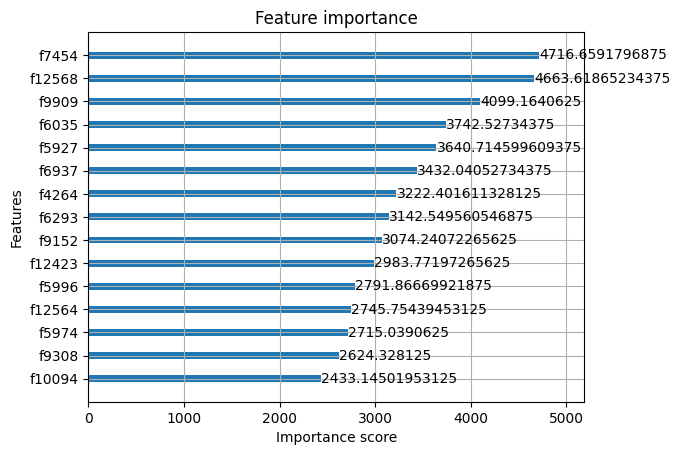

In [24]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

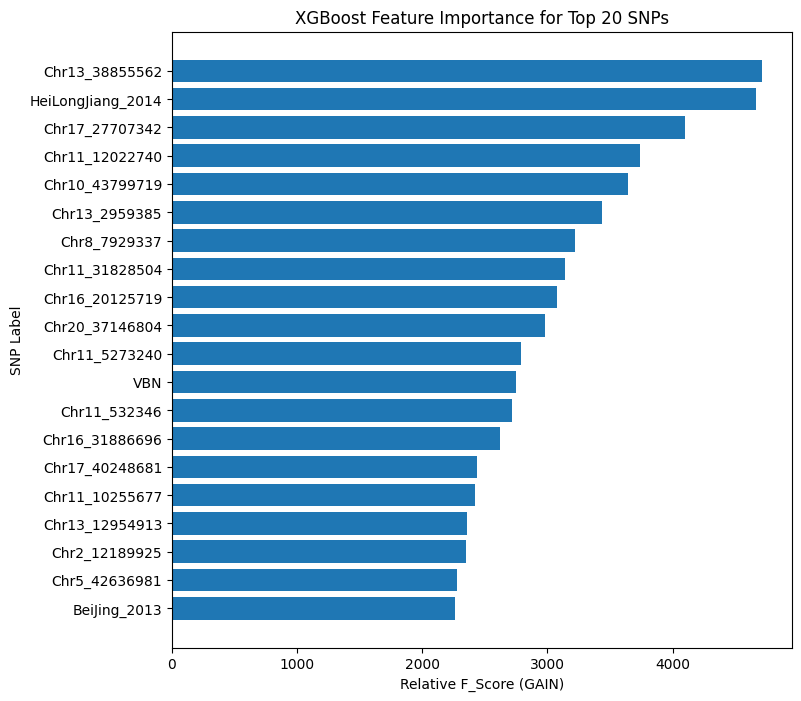

In [25]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_all_dupe, top_n=20)

In [26]:
explainer = shap.Explainer(best_xgbr_model)

In [27]:
shap_values = explainer(gwas_all_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

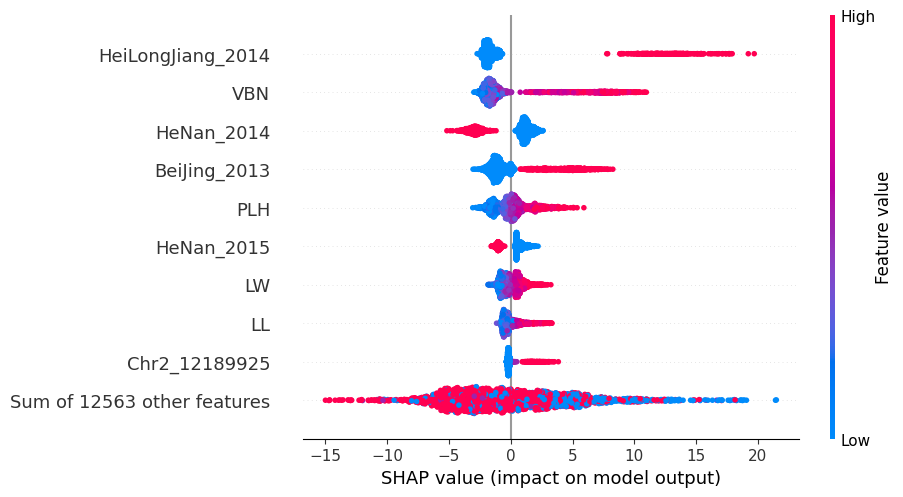

In [28]:
shap.plots.beeswarm(shap_values, show=False)

In [16]:
holdout_data = pd.read_pickle("../pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [17]:
holdout_data = holdout_data.set_index('Line')

In [18]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [19]:
X_holdout = holdout_data.iloc[:, 0:251240]

In [20]:
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [21]:
y_holdout = holdout_data.iloc[:, 251240:]

In [22]:
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [23]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [24]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 12572 entries, Chr1_124994 to landrace
dtypes: float64(4), int64(12568)
memory usage: 60.8+ MB


In [25]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.78
RMSE of Holdout: 6.47
Mean of Holdout: 47.16
This is 13.71% of the mean pheno data
0 45 44.669983
1 39 53.036972
2 62 64.540695
3 47 51.514637
4 42 44.853477


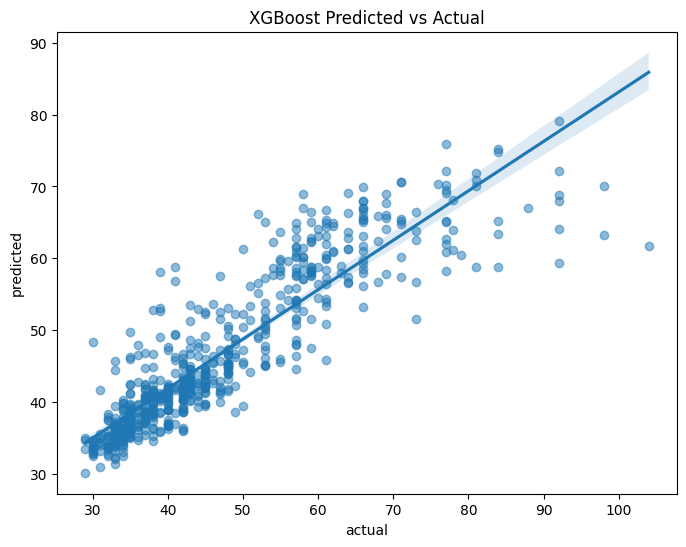

In [26]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [41]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 45 44.669983
1 39 53.036972
2 62 64.540695
3 47 51.514637
4 42 44.853477
5 40 40.37152


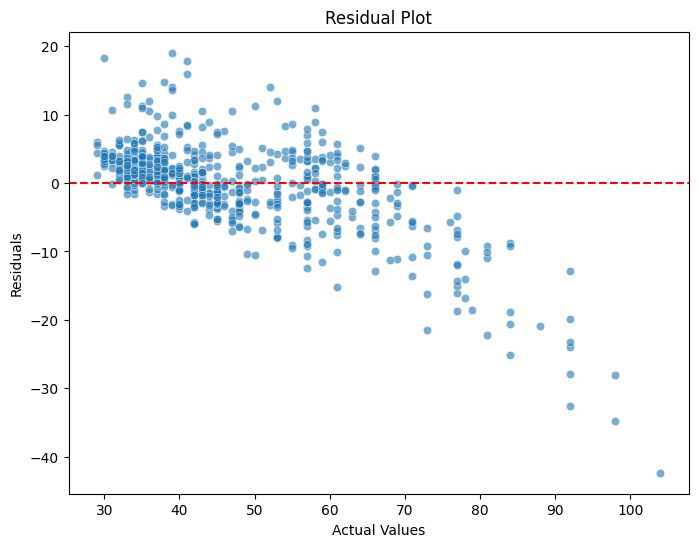

In [42]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [43]:
#### RF models

In [44]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 23), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 10), ('min_samples_split', 11), ('n_estimators', 115)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 23), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 10), ('min_samples_split', 11), ('n_estimators', 115)])

In [45]:
best_rfr_model = eval_k_fold(best_rfreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.754879016141762
RMSE for dataset is:12.199989683628568& mean of this fold is 46.031496062992126
this is 26.503569788245436% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.789183761122998
RMSE for dataset is:10.422139662863032& mean of this fold is 44.468503937007874
this is 23.437126820426826% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.489612380257061
RMSE for dataset is:12.14341340194036& mean of this fold is 47.61417322834646
this is 25.50377876709816% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.276813723583148
RMSE for dataset is:10.922329437248166& mean of this fold is 46.003937007874015
this is 23.742162405314797% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.148323941386501
RMSE for 

In [47]:
pickle.dump(best_rfr_model, open("gwas_top5_allfeats_rfr_bbd.pickle.dat", "wb"))

In [27]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top5_allfeats_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.22
RMSE of Holdout: 12.23
Mean of Holdout: 47.16
This is 25.94% of the mean pheno data
0 45 52.24746947405995
1 39 49.221033368430255
2 62 49.24843854384456
3 47 52.198807482200486
4 42 45.14169954170503


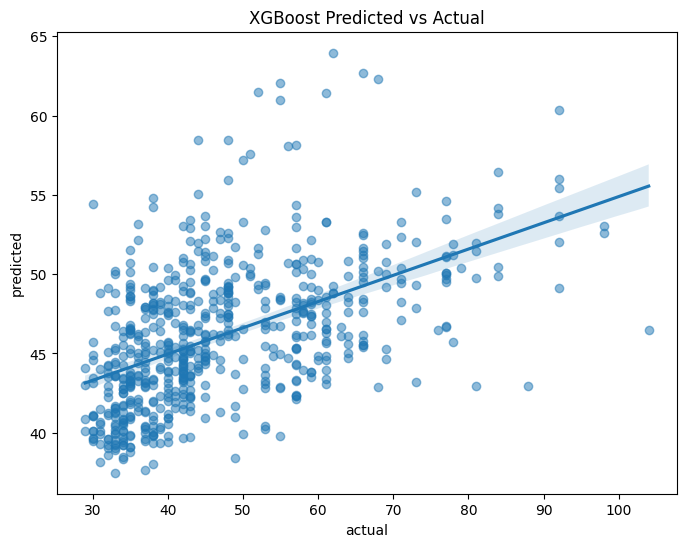

In [28]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [34]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [35]:
gwas_all = gwas_all.to_numpy()
gwas_y = gwas_y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.735017448891139
RMSE for dataset is:6.708427935602879& mean of this fold is 46.25196850393701
this is 14.50409172321358% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7244164993669584
RMSE for dataset is:5.9850910627159015& mean of this fold is 45.476377952755904
this is 13.160878970910217% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7407150084768033
RMSE for dataset is:6.149644686436476& mean of this fold is 46.46456692913386
this is 13.235127523766014% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.8219563414285824
RMSE for dataset is:5.544407505467982& mean of this fold is 46.188976377952756
this is 12.00374621879362% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7746017102911474
RMSE for datas

In [36]:
pickle.dump(best_svr_model, open("gwas_top5_allfeats_svr_bbd.pickle.dat", "wb"))

In [29]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top5_allfeats_svr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.75
RMSE of Holdout: 6.99
Mean of Holdout: 47.16
This is 14.81% of the mean pheno data
0 45 52.74226678822571
1 39 50.00516013688804
2 62 70.75045252082873
3 47 60.60636528051395
4 42 41.61866178857457


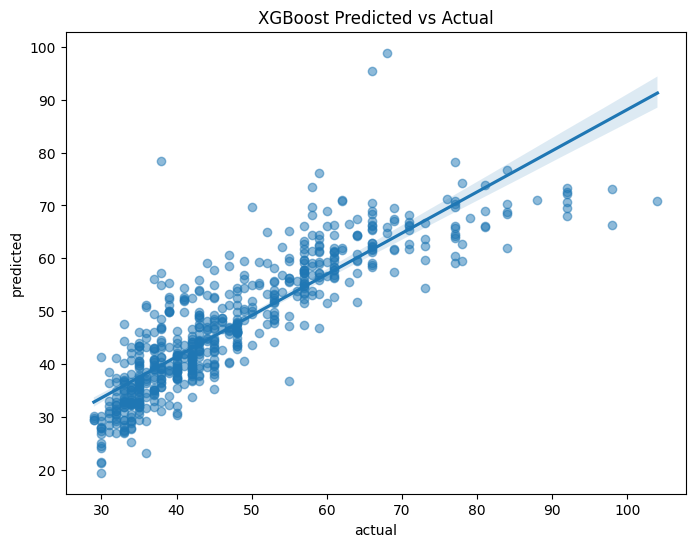

In [30]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only SNPs

In [31]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 12573 entries, Chr1_124994 to BBD
dtypes: float64(4), int64(12569)
memory usage: 243.3+ MB


In [32]:
gwas_snps = gwas_data.iloc[:, 0:12561]
gwas_snps.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51494122,Chr20_51594636,Chr20_51666785,Chr20_51684283,Chr20_51840551,Chr20_51859725,Chr20_51891017,Chr20_51977670,Chr20_52108115,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s101,1,0,0,0,0,0,1,0,0,0,...,2,1,1,2,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [33]:
gwas_snps_dupe = gwas_data.iloc[:, 0:12561]
gwas_snps_dupe.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51494122,Chr20_51594636,Chr20_51666785,Chr20_51684283,Chr20_51840551,Chr20_51859725,Chr20_51891017,Chr20_51977670,Chr20_52108115,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s101,1,0,0,0,0,0,1,0,0,0,...,2,1,1,2,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [34]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


# Run models

In [42]:
X_train, X_test, y_train, y_test = train_test_split(gwas_snps, gwas_y, test_size=0.1, random_state=42)

In [43]:
X_train.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51494122,Chr20_51594636,Chr20_51666785,Chr20_51684283,Chr20_51840551,Chr20_51859725,Chr20_51891017,Chr20_51977670,Chr20_52108115,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s2502,0,2,0,0,0,0,2,0,0,2,...,2,0,0,2,0,0,0,0,0,0
s286,0,0,0,0,0,0,1,0,0,0,...,2,0,0,0,0,0,0,0,0,0
s382,0,0,0,2,2,0,0,2,0,0,...,0,0,0,2,0,0,0,0,0,0
s789,1,1,1,0,0,0,2,0,0,2,...,2,0,0,2,0,0,0,0,0,0
s691,0,0,0,2,0,0,1,0,0,0,...,2,2,0,2,0,0,0,0,0,0


In [44]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [55]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.14638413202022832), ('colsample_bytree', 0.12268563166303768), ('gamma', 0.003272909619989833), ('learning_rate', 0.04299471176755962), ('max_delta_step', 13), ('max_depth', 1), ('min_child_weight', 3), ('n_estimators', 187), ('reg_alpha', 0.7519510777663355), ('reg_lambda', 1.0193603023879012e-05), ('subsample', 0.25155383002194887)])


In [54]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.14638413202022832), ('colsample_bytree', 0.12268563166303768), ('gamma', 0.003272909619989833), ('learning_rate', 0.04299471176755962), ('max_delta_step', 13), ('max_depth', 1), ('min_child_weight', 3), ('n_estimators', 187), ('reg_alpha', 0.7519510777663355), ('reg_lambda', 1.0193603023879012e-05), ('subsample', 0.25155383002194887)])

OrderedDict([('colsample_bylevel', 0.9132100359267209), ('colsample_bytree', 0.7679711803126804), ('gamma', 2.428808912219129e-07), ('learning_rate', 0.03511167856740689), ('max_delta_step', 3), ('max_depth', 8), ('min_child_weight', 4), ('n_estimators', 197), ('reg_alpha', 0.023358352781682152), ('reg_lambda', 2.1396512525873352e-07), ('scale_pos_weight', 0.001760608876847004), ('subsample', 0.15990388740095085)])


In [56]:
gwas_snps = gwas_snps.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.27760320115786
RMSE for dataset is:12.654929088360726& mean of this fold is 46.37795275590551
this is 27.286519426516335% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -16.086079337634853
RMSE for dataset is:12.689005304413627& mean of this fold is 46.95275590551181
this is 27.025049030027347% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.036536029448259
RMSE for dataset is:11.537171410150869& mean of this fold is 45.838582677165356
this is 25.16912770057821% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.089155527843237
RMSE for dataset is:11.291755062556616& mean of this fold is 45.06299212598425
this is 25.057712614794518% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.646307001192875
RMSE for 

In [57]:
pickle.dump(best_xgbr_model, open("gwas_top5_onlysnps_xgbr_bbd.pickle.dat", "wb"))

In [35]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top5_onlysnps_xgbr_bbd.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

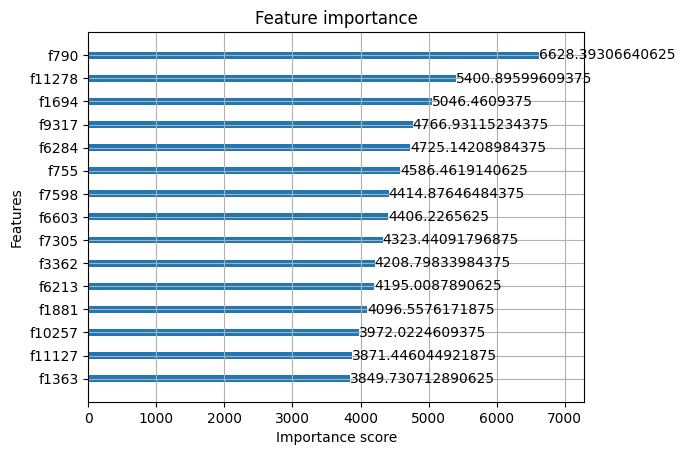

In [58]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

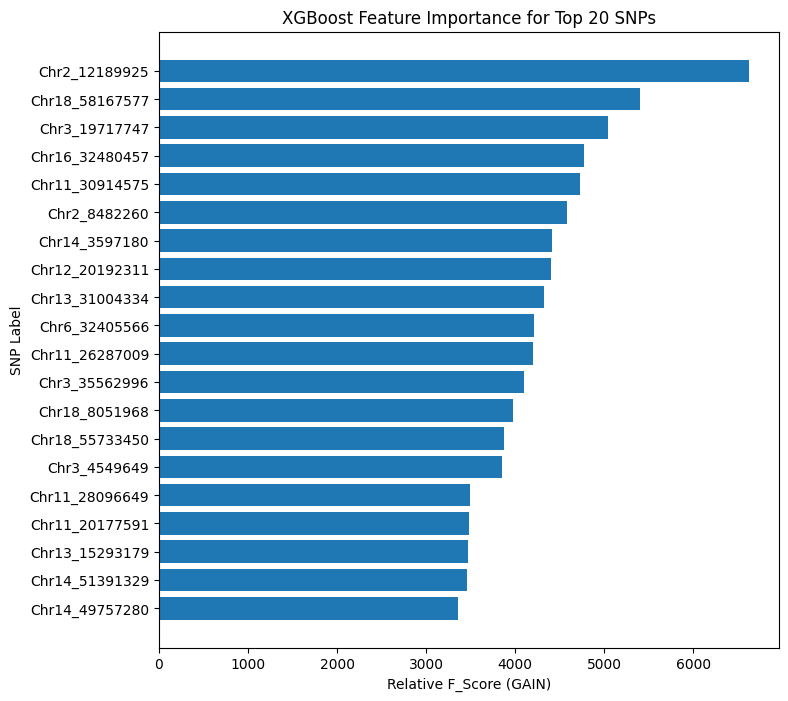

In [59]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_snps_dupe , top_n=20)

In [60]:
explainer = shap.Explainer(best_xgbr_model)

In [61]:
shap_values = explainer(gwas_snps_dupe)

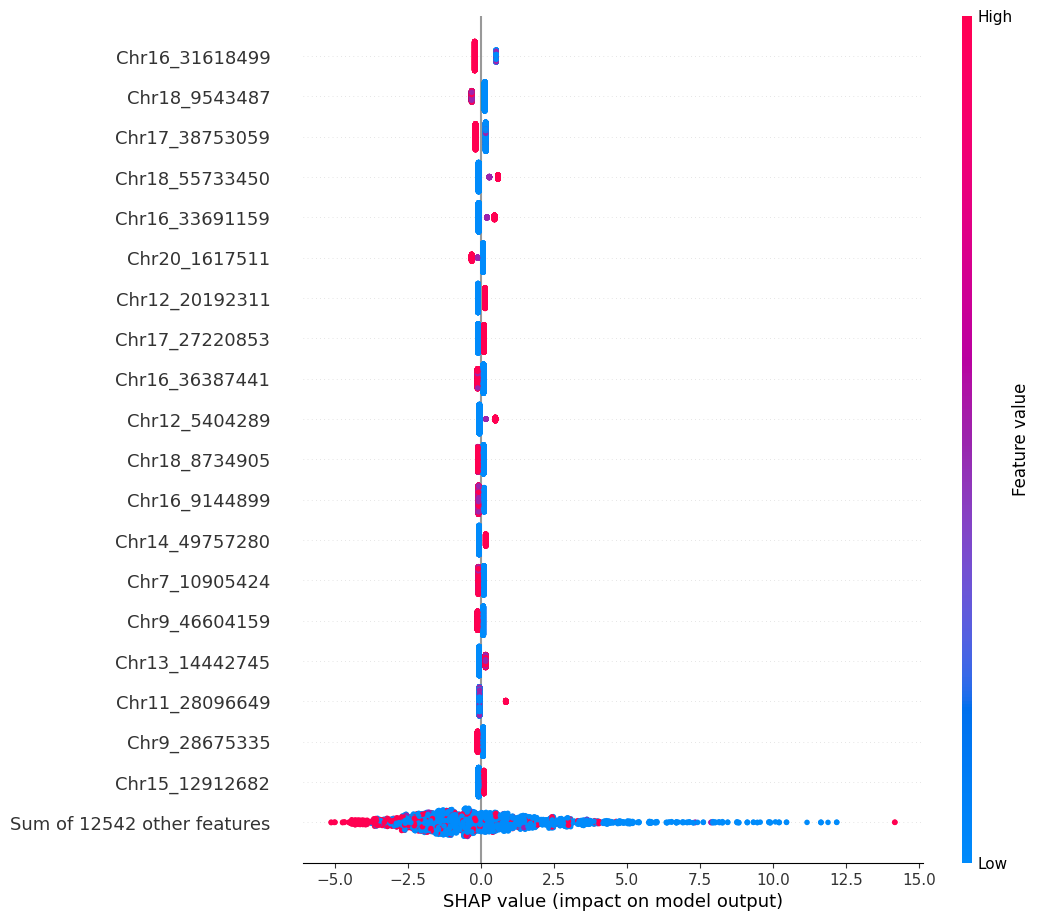

In [62]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])


In [36]:
holdout_data = pd.read_pickle("../pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [37]:
holdout_data = holdout_data.set_index('Line')

In [38]:
holdout_data= holdout_data.drop(['new_line'], axis=1)

KeyError: "['new_line'] not found in axis"

In [39]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [40]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [41]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [42]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 12561 entries, Chr1_124994 to Chr20_52247340
dtypes: int64(12561)
memory usage: 60.8+ MB


In [43]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.12
RMSE of Holdout: 13.00
Mean of Holdout: 47.16
This is 27.56% of the mean pheno data
0 45 48.114357
1 39 46.70353
2 62 46.70353
3 47 48.25418
4 42 46.122887


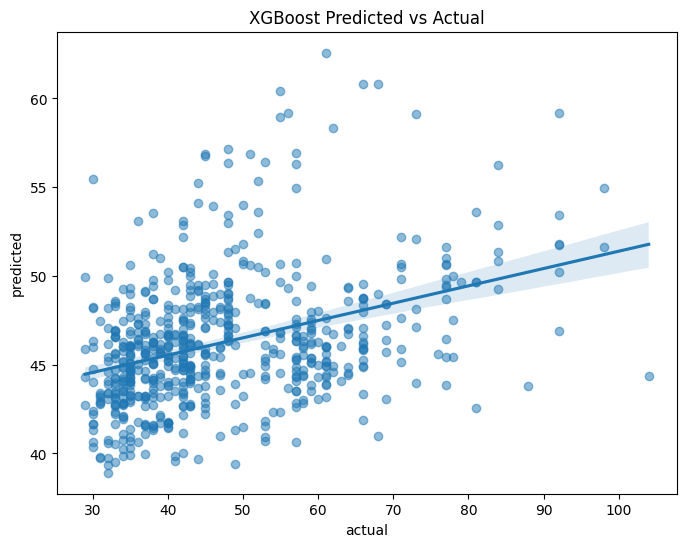

In [44]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [103]:
#### RF models

In [72]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 21), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 19), ('n_estimators', 500)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 21), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 19), ('n_estimators', 500)])

In [73]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -14.43161367153147
RMSE for dataset is:13.53742297742343& mean of this fold is 46.29527559055118
this is 29.24147832524493% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.422965657487897
RMSE for dataset is:11.883223895505864& mean of this fold is 45.51968503937008
this is 26.105681278831426% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.280008331822758
RMSE for dataset is:11.096522676168496& mean of this fold is 45.22834645669291
this is 24.53444254654246% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.987113670061179
RMSE for dataset is:11.730805695628167& mean of this fold is 45.696850393700785
this is 25.670928290596663% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -11.47309742236647
RMSE for dat

In [74]:
pickle.dump(best_rfr_model, open("gwas_top5_onlysnps_rfr_bbd.pickle.dat", "wb"))

In [47]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top5_onlysnps_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.09
RMSE of Holdout: 13.21
Mean of Holdout: 47.16
This is 28.01% of the mean pheno data
0 45 52.60702084356253
1 39 47.24178260507426
2 62 47.24178260507426
3 47 45.42477997983962
4 42 45.55894529602526


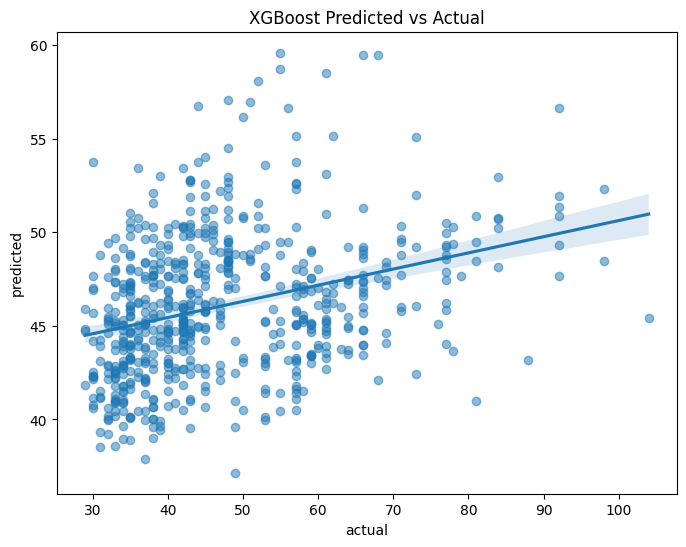

In [48]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [52]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 3), ('kernel', 'sigmoid')])


In [53]:
gwas_snps = gwas_snps.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -18.794160361116834
RMSE for dataset is:12.344524590247032& mean of this fold is 45.81496062992126
this is 26.944309065246593% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -18.894497832966067
RMSE for dataset is:12.00842082948438& mean of this fold is 45.29133858267716
this is 26.513724710440133% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -26.765353120266646
RMSE for dataset is:14.478142606508802& mean of this fold is 47.07874015748032
this is 30.75303748162933% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -20.912446533243855
RMSE for dataset is:12.764505665278463& mean of this fold is 45.65748031496063
this is 27.957096136765795% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -14.143688279987272
RMSE fo

In [54]:
pickle.dump(best_svr_model, open("gwas_top5_onlysnps_svr_bbd.pickle.dat", "wb"))

In [45]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top5_onlysnps_svr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.01
RMSE of Holdout: 13.79
Mean of Holdout: 47.16
This is 29.24% of the mean pheno data
0 45 44.90080958592369
1 39 43.02389854341857
2 62 43.02389854341857
3 47 42.605842947291954
4 42 42.60979023607499


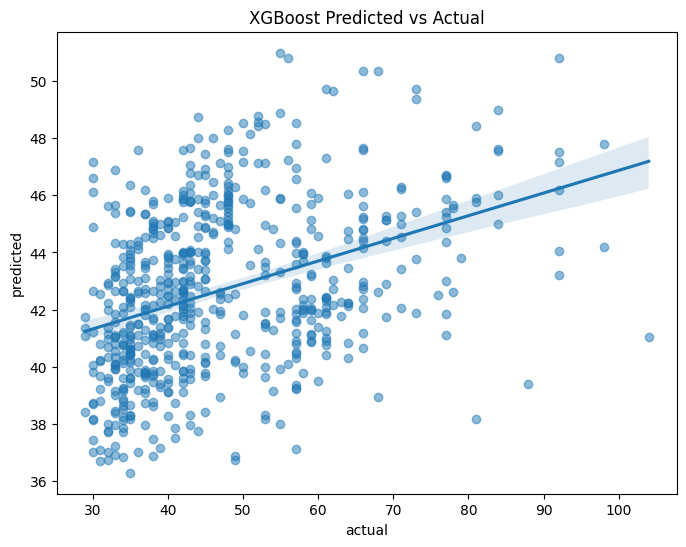

In [46]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only location

In [49]:
gwas_loc= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51977670,Chr20_52108115,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,0,0,1,0,0,0,1
s101,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1


In [50]:
gwas_loc_dupe= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc_dupe.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51977670,Chr20_52108115,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,0,0,1,0,0,0,1
s101,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1


In [51]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 12568 entries, Chr1_124994 to landrace
dtypes: int64(12568)
memory usage: 243.2+ MB


In [52]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [53]:
# Run models

In [61]:
X_train, X_test, y_train, y_test = train_test_split(gwas_loc, gwas_y, test_size=0.1, random_state=42)

In [62]:
X_train.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51977670,Chr20_52108115,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2502,0,2,0,0,0,0,2,0,0,2,...,0,0,0,0,0,1,0,0,1,0
s286,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
s382,0,0,0,2,2,0,0,2,0,0,...,0,0,0,0,1,0,0,0,0,1
s789,1,1,1,0,0,0,2,0,0,2,...,0,0,0,0,0,1,0,0,1,0
s691,0,0,0,2,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0


In [63]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [64]:
print(y_train[~np.isfinite(y_train)])

[]


In [109]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.6991444150010883), ('colsample_bytree', 0.7332358554223284), ('gamma', 0.0009119141116322349), ('learning_rate', 0.023895235602058734), ('max_delta_step', 20), ('max_depth', 46), ('min_child_weight', 4), ('n_estimators', 200), ('reg_alpha', 0.0005207668250837369), ('reg_lambda', 1.4862354153856118e-06), ('subsample', 0.6802417814536137)])


In [70]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.6991444150010883), ('colsample_bytree', 0.7332358554223284), ('gamma', 0.0009119141116322349), ('learning_rate', 0.023895235602058734), ('max_delta_step', 20), ('max_depth', 46), ('min_child_weight', 4), ('n_estimators', 200), ('reg_alpha', 0.0005207668250837369), ('reg_lambda', 1.4862354153856118e-06), ('subsample', 0.6802417814536137)])


OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 2), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('scale_pos_weight', 0.060830282487222144), ('subsample', 0.13556548021189216)])


In [111]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5993797362222949
RMSE for dataset is:6.631981934439444& mean of this fold is 47.54724409448819
this is 13.94819418189632% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5002730382424609
RMSE for dataset is:7.049799450382539& mean of this fold is 45.826771653543304
this is 15.383582993102793% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.640254737332981
RMSE for dataset is:6.02608202521107& mean of this fold is 45.97244094488189
this is 13.108031467017314% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5244664321736194
RMSE for dataset is:6.770920619645936& mean of this fold is 45.79527559055118
this is 14.78519461305079% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7304366998869756
RMSE for dataset 

In [55]:
#pickle.dump(best_xgbr_model, open("gwas_top5_onlyloc_xgbr_bbd.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top5_onlyloc_xgbr_bbd.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

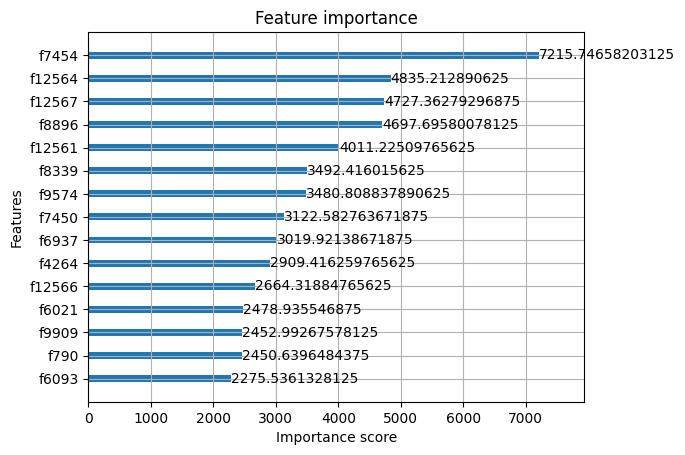

In [28]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

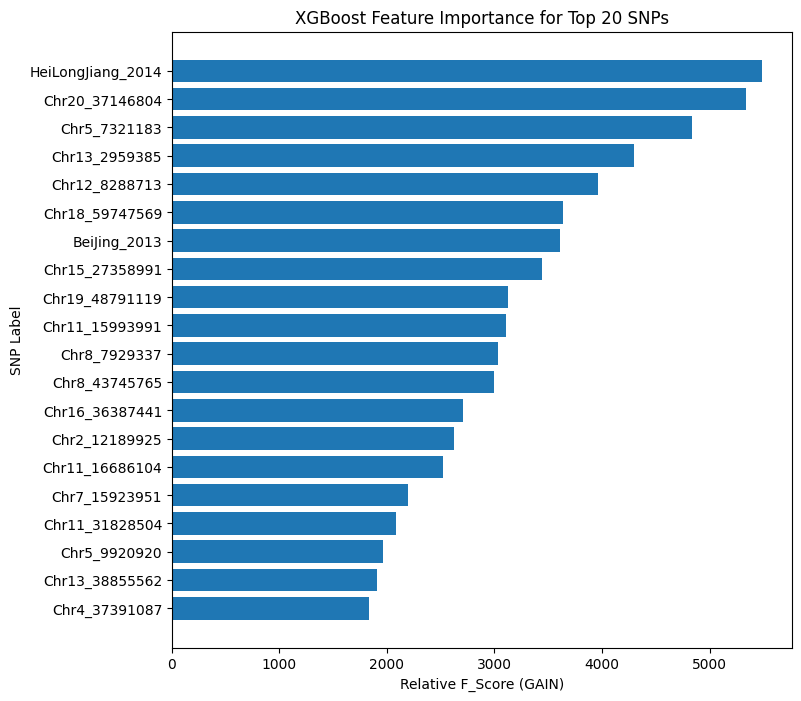

In [112]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_loc_dupe, top_n=20)

In [113]:
explainer = shap.Explainer(best_xgbr_model)

In [115]:
shap_values = explainer(gwas_loc_dupe, check_additivity=False)

<Axes: xlabel='SHAP value (impact on model output)'>

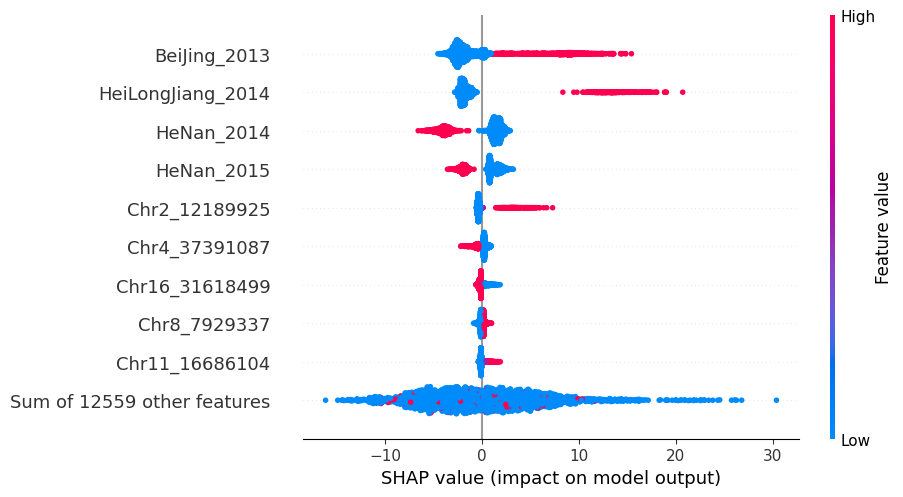

In [116]:
shap.plots.beeswarm(shap_values, show=False)

In [65]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [66]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [56]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [57]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [58]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [59]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 12568 entries, Chr1_124994 to landrace
dtypes: int64(12568)
memory usage: 60.8+ MB


In [60]:
X_holdout.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51977670,Chr20_52108115,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
s101,1,0,0,0,0,0,1,0,0,0,...,0,0,1,1,0,0,0,0,0,1
s101,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,1,0,0,1
s1026,1,1,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,1
s1030,1,1,1,2,1,0,1,2,0,0,...,0,0,0,0,1,0,0,0,0,1


In [61]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.77
RMSE of Holdout: 6.70
Mean of Holdout: 47.16
This is 14.20% of the mean pheno data
0 45 45.178234
1 39 56.46895
2 62 63.513863
3 47 52.896378
4 42 41.247116


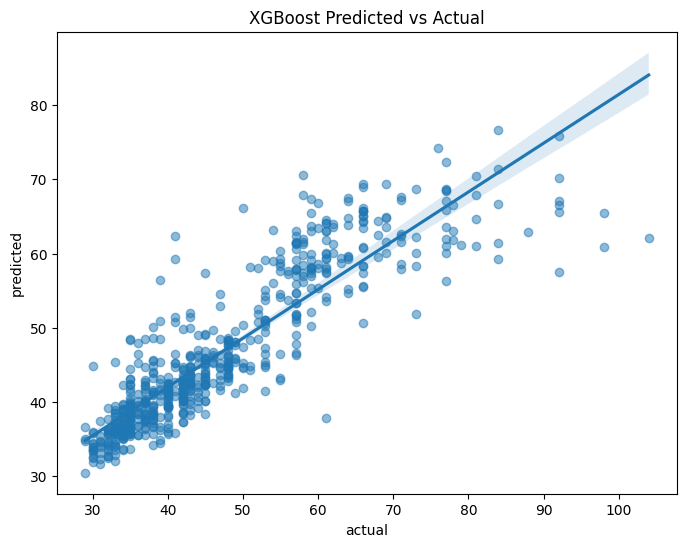

In [62]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [120]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])


0 45 45.178234
1 39 56.46895
2 62 63.513863
3 47 52.896378
4 42 41.247116
5 40 40.65675


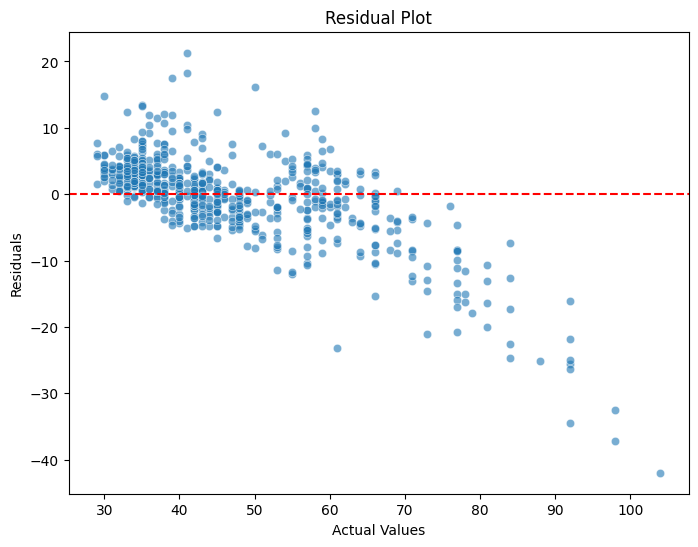

In [121]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [104]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 33), ('max_features', 'sqrt'), ('max_samples', 0.8149505332405951), ('min_samples_leaf', 10), ('min_samples_split', 16), ('n_estimators', 225)])


In [2]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 41), ('max_features', 'sqrt'), ('max_samples', 0.9550174252643964), ('min_samples_leaf', 3), ('min_samples_split', 15), ('n_estimators', 223)])

In [106]:
gwas_loc = gwas_loc.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.17106175795322
RMSE for dataset is:12.088333808421918& mean of this fold is 45.70866141732284
this is 26.446483956409704% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.6025207337426135
RMSE for dataset is:11.667805544957812& mean of this fold is 45.81496062992126
this is 25.467239051467594% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.727090791630296
RMSE for dataset is:11.566783148511236& mean of this fold is 46.64173228346457
this is 24.799214313512735% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.079499232299517
RMSE for dataset is:12.55888682663196& mean of this fold is 46.224409448818896
this is 27.16938296537363% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.407824980833944
RMSE for d

In [108]:
pickle.dump(best_rfr_model, open("gwas_top5_onlyloc_rfr_bbd.pickle.dat", "wb"))

In [65]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top5_onlyloc_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.17
RMSE of Holdout: 12.61
Mean of Holdout: 47.16
This is 26.74% of the mean pheno data
0 45 51.29772667016514
1 39 48.589941468897045
2 62 49.28849254672529
3 47 51.223162637632946
4 42 45.01156842799715


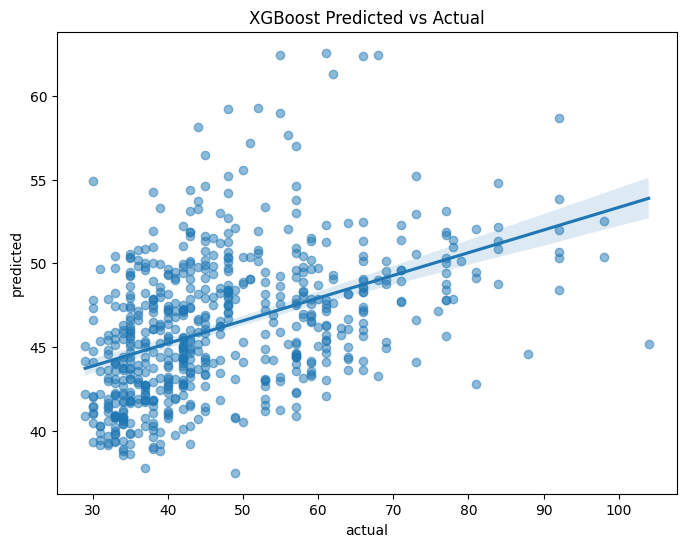

In [66]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [73]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [74]:
gwas_loc = gwas_loc.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7652426068256958
RMSE for dataset is:5.7939718495884645& mean of this fold is 44.830708661417326
this is 12.924113900021691% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6455921945200651
RMSE for dataset is:6.909238442793013& mean of this fold is 45.71259842519685
this is 15.11451696209995% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7391566804962226
RMSE for dataset is:6.212338462981424& mean of this fold is 47.09842519685039
this is 13.190119281094054% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7442654786902195
RMSE for dataset is:5.848164247413834& mean of this fold is 46.531496062992126
this is 12.568184438980573% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6799316951816909
RMSE for dat

In [75]:
pickle.dump(best_svr_model, open("gwas_top5_onlyloc_svr_bbd.pickle.dat", "wb"))

In [63]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top5_onlyloc_svr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.73
RMSE of Holdout: 7.25
Mean of Holdout: 47.16
This is 15.37% of the mean pheno data
0 45 55.50007630203331
1 39 50.97491103332947
2 62 70.97487179308976
3 47 59.12133650853676
4 42 39.50046210624752


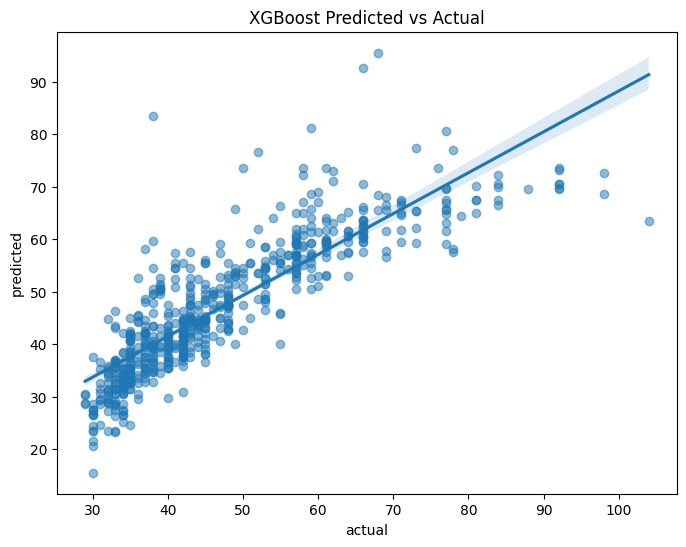

In [64]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)